In [6]:
from implementations import *
import numpy as np
from helpers import *

# x_train, x_test, y_train, train_ids, test_ids = load_csv_data("data/dataset")
# loading is too slow, I use this for testing -M
path_to_dataset = "data/dataset"
x_train, x_test, y_train, train_ids, test_ids = load_csv_data(
    path_to_dataset, max_rows=500, NaNstrat="fill"
)
tx, mask = preprocess_structural(x_train, ones=True)
tx = preprocess_unstructural(tx)
x_test = x_test[:, mask]

In [7]:
tx_train_split, tx_test_split, y_train_split, y_test_split = split_data(tx, y_train)

In [8]:
w0 = np.zeros(tx.shape[1])
max_iters = 1000
gamma = 0.1  # empirically these gamma values seems to work alright -M

w1, loss1 = mean_squared_error_gd(y_train_split, tx_train_split, w0, max_iters, gamma)


(100, 322) (322,)
(100,) (100,) (2, 2)


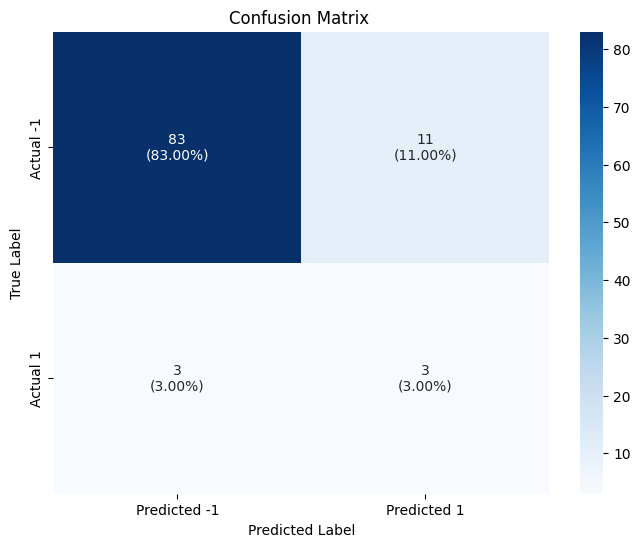

In [9]:
y_pred = tx_test_split @ w1
print(tx_test_split.shape, w1.shape)

# Convert predictions to binary labels (-1 or 1)
y_pred_binary = np.where(y_pred >= 0, 1, -1)

cm = create_confusion_matrix(y_test_split, y_pred_binary)

_ = cm_visualization(cm)

print(y_pred.shape, y_pred_binary.shape, cm.shape)

In [10]:
w0 = np.zeros(tx.shape[1])
max_iters = 1000
gamma_sgd = 0.001

w2, loss2 = mean_squared_error_sgd(y_train_split, tx_train_split, w0, max_iters, gamma_sgd)

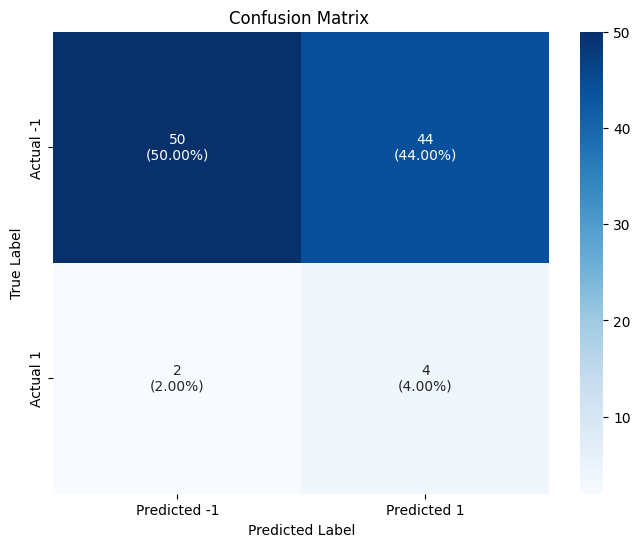

In [11]:
y_pred = tx_test_split @ w2

# Convert predictions to binary labels (-1 or 1)
y_pred_binary = np.where(y_pred >= 0, 1, -1)

cm = create_confusion_matrix(y_test_split, y_pred_binary)

_ = cm_visualization(cm)

In [12]:
w3, loss3 = least_squares(y_train_split, tx_train_split)

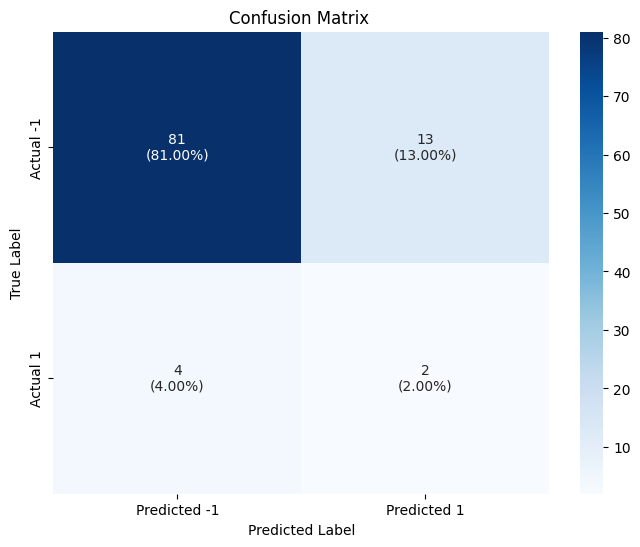

In [13]:
y_pred = tx_test_split @ w3

# Convert predictions to binary labels (-1 or 1)
y_pred_binary = np.where(y_pred >= 0, 1, -1)

cm = create_confusion_matrix(y_test_split, y_pred_binary)

_ = cm_visualization(cm)

In [14]:
lambda_ = 0.1  # I guess the regularization param in ridge doesn't have to be very big for standardized data -M

w4, loss4 = ridge_regression(y_train_split, tx_train_split, lambda_)

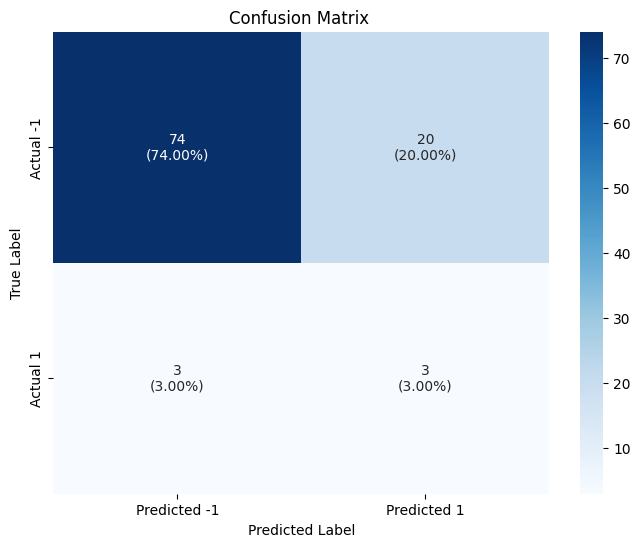

In [15]:
y_pred = tx_test_split @ w4

# Convert predictions to binary labels (-1 or 1)
y_pred_binary = np.where(y_pred >= 0, 1, -1)

cm = create_confusion_matrix(y_test_split, y_pred_binary)

_ = cm_visualization(cm)

In [16]:
w0 = np.zeros(tx.shape[1])
max_iters = 1000
gamma_logistic = 0.001

w5, loss5 = logistic_regression(y_train_split, tx_train_split, w0, max_iters, gamma_logistic)

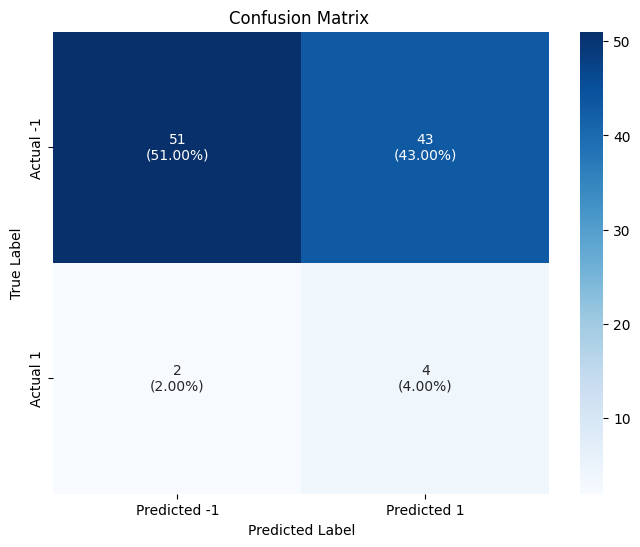

In [17]:
y_pred = tx_test_split @ w5

# Convert predictions to binary labels (-1 or 1)
y_pred_binary = np.where(y_pred >= 0, 1, -1)

cm = create_confusion_matrix(y_test_split, y_pred_binary)

_ = cm_visualization(cm)

In [18]:
w0 = np.zeros(tx.shape[1])
max_iters = 1000
gamma_logistic = 0.001
lambda_LR = 0.1

w6, loss6 = reg_logistic_regression(
    y_train_split, tx_train_split, lambda_LR, w0, max_iters, gamma_logistic
)

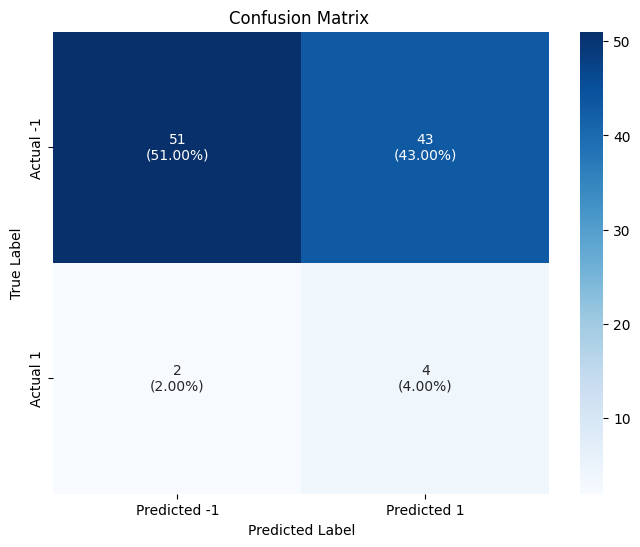

In [19]:
y_pred = tx_test_split @ w6

# Convert predictions to binary labels (-1 or 1)
y_pred_binary = np.where(y_pred >= 0, 1, -1)

cm = create_confusion_matrix(y_test_split, y_pred_binary)

_ = cm_visualization(cm)